<a href="https://colab.research.google.com/github/Faizzyyy13/WNN-Human-Activity-Recognition/blob/main/WNN_WISDOM_V2_RESULTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import gc
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif
from tensorflow.keras.layers import (Layer, Input, Conv1D, BatchNormalization,
                                     MaxPooling1D, GlobalAveragePooling1D,
                                     Dense, Concatenate, Dropout, Lambda,
                                     SpatialDropout1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import NonNeg
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

# =====================================================================
# 1. CUSTOM LAYERS & ARCHITECTURE
# =====================================================================
def morlet_wavelet(t):
    return tf.exp(-(t**2) / 2.0) * tf.cos(5.0 * t)

class SensorAugmentation(Layer):
    """Adds Random Jitter and Scaling to simulate different physical device wearing styles."""
    def __init__(self, noise_std=0.01, scale_range=0.05, **kwargs):
        super(SensorAugmentation, self).__init__(**kwargs)
        self.noise_std = noise_std
        self.scale_range = scale_range

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=self.noise_std)
            scale = tf.random.uniform(shape=(tf.shape(inputs)[0], 1, tf.shape(inputs)[2]),
                                      minval=1.0 - self.scale_range,
                                      maxval=1.0 + self.scale_range)
            return (inputs * scale) + noise
        return inputs

class SelectedGroupedWaveletLayer(Layer):
    def __init__(self, selected_indices, original_group_indices, **kwargs):
        super(SelectedGroupedWaveletLayer, self).__init__(**kwargs)
        self.useful_groups = [original_group_indices[i] for i in selected_indices]
        self.num_sums = len(self.useful_groups)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        mask_array = np.zeros((input_dim, self.num_sums), dtype='float32')
        for col_idx, group in enumerate(self.useful_groups):
            for row_idx in group:
                mask_array[row_idx, col_idx] = 1.0

        self.connectivity_mask = tf.constant(mask_array, dtype=tf.float32)
        self.weights_conn = self.add_weight(name='weights_conn', shape=(input_dim, self.num_sums),
                                            initializer='glorot_uniform', trainable=True)
        self.scale = self.add_weight(name='scale', shape=(1, self.num_sums),
                                     initializer='ones', trainable=True, constraint=NonNeg())
        self.translation = self.add_weight(name='translation', shape=(1, self.num_sums),
                                           initializer='zeros', trainable=True)
        super(SelectedGroupedWaveletLayer, self).build(input_shape)

    def call(self, inputs):
        masked_weights = self.weights_conn * self.connectivity_mask
        x_weighted = tf.matmul(inputs, masked_weights)
        return morlet_wavelet((x_weighted - self.translation) / (self.scale + 1e-8))

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.num_sums,)

def build_wisdm_v2_hybrid(input_shape, num_classes, selected_indices, original_groups):
    inputs = Input(shape=input_shape)
    x_aug = SensorAugmentation()(inputs)
    x_wavelet = SelectedGroupedWaveletLayer(selected_indices, original_groups)(x_aug)

    # --- FAST DYNAMIC BRANCH (Pure CNN) ---
    x_dyn = Conv1D(64, 7, activation='relu', padding='same')(x_wavelet)
    x_dyn = BatchNormalization()(x_dyn)
    x_dyn = MaxPooling1D(2)(x_dyn)
    x_dyn = SpatialDropout1D(0.2)(x_dyn)

    x_dyn = Conv1D(128, 5, activation='relu', padding='same')(x_dyn)
    x_dyn = BatchNormalization()(x_dyn)
    x_dyn = GlobalAveragePooling1D()(x_dyn)

    # --- STATIC BRANCH (Gravity Posture) ---
    x_static = GlobalAveragePooling1D()(x_aug)
    x_static = Dense(16, activation='relu')(x_static)

    # --- FUSION ---
    x_final = Concatenate()([x_dyn, x_static])
    x_final = Dense(64, activation='relu')(x_final)
    x_final = Dropout(0.4)(x_final) # 0.4 dropout helps with the 18 classes
    outputs = Dense(num_classes, activation='softmax')(x_final)

    return Model(inputs, outputs, name="Standard_WISDMv2_CNN")

# =====================================================================
# 2. DATA LOADER (WISDM v2 CSV LOADER)
# =====================================================================
def load_wisdm_v2_standard(file_path, window_size=200, step_size=100):
    print(f"Loading WISDM v2 Combined dataset from {file_path}...")
    df = pd.read_csv(file_path).dropna()

    # Assuming channels are in columns 3 to 12 (9 channels)
    feature_cols = df.columns[3:12]

    print("Sanitizing feature columns to ensure pure float values...")
    for col in feature_cols:
        if df[col].dtype == 'object' or df[col].dtype == 'str':
            df[col] = df[col].astype(str).str.replace(';', '', regex=False).astype(float)

    all_X, all_y = [], []

    print(f"Applying sliding window (Size: {window_size}, Step: {step_size})...")
    # Group by User and Activity to ensure windows do not cross activity/user boundaries
    for (user, activity), group in df.groupby(['User', 'Activity']):
        features = group[feature_cols].values

        for i in range(0, len(features) - window_size, step_size):
            window = features[i:i + window_size]
            if len(window) == window_size:
                all_X.append(window)
                all_y.append(activity)

    return np.array(all_X), np.array(all_y)

# =====================================================================
# 3. STANDARD 80/20 TRAINING EXECUTION
# =====================================================================
if __name__ == "__main__":
    # --- LOCAL PATH ---
    COMBINED_CSV_PATH = r'/content/wisdom_p&w_combined.csv'
    WINDOW_SIZE = 200

    if not os.path.exists(COMBINED_CSV_PATH):
        print(f"ERROR: {COMBINED_CSV_PATH} does not exist. Check your path.")
    else:
        print("\n1. Loading and Windowing WISDM v2 Data...")
        X_raw, y_raw = load_wisdm_v2_standard(COMBINED_CSV_PATH, window_size=WINDOW_SIZE, step_size=100)

        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y_raw)
        y_all_hot = to_categorical(y_encoded)
        num_classes = len(encoder.classes_)
        N_FEATURES = X_raw.shape[-1]

        print(f"Total Windows: {X_raw.shape[0]} | Total Classes: {num_classes} | Input Channels: {N_FEATURES}")

        # Generate Full Power Set Combinations (2^9 - 1 = 511 combinations)
        print("\n2. Generating Full Power Set Sensor Combinations...")
        feature_indices = list(range(N_FEATURES))
        original_groups = []
        for r in range(1, N_FEATURES + 1):
            original_groups.extend(list(itertools.combinations(feature_indices, r)))
        print(f"Total Wavelet Channels Generated: {len(original_groups)}")

        # Standard Random Split (80% Train, 20% Test)
        print("\n3. Splitting Data into 80% Training and 20% Testing...")
        y_sparse = np.argmax(y_all_hot, axis=1)

        try:
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y_all_hot, test_size=0.2, stratify=y_sparse, random_state=42
            )
        except ValueError:
            print("  [Notice] Highly imbalanced classes detected. Falling back to unstratified split.")
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y_all_hot, test_size=0.2, random_state=42
            )

        del X_raw, y_all_hot
        gc.collect()

        # Scaling Data (Fit strictly on Training set to avoid data leakage)
        print("\n4. Scaling Features (Z-Score Normalization)...")
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train_raw.reshape(-1, N_FEATURES)).reshape(X_train_raw.shape)
        X_test_sc = scaler.transform(X_test_raw.reshape(-1, N_FEATURES)).reshape(X_test_raw.shape)

        del X_train_raw, X_test_raw
        gc.collect()

        # Fast Feature Selection (ANOVA F-Statistic)
        print("\n5. Performing ANOVA Feature Selection to extract Top 50 Channels...")
        temp_inputs = Input(shape=(WINDOW_SIZE, N_FEATURES))
        # Feed all 511 combinations into the temporary layer
        temp_layer = SelectedGroupedWaveletLayer(list(range(len(original_groups))), original_groups)(temp_inputs)
        squared_layer = Lambda(lambda x: tf.square(x))(temp_layer)
        energy_layer = GlobalAveragePooling1D()(squared_layer)
        temp_model = Model(inputs=temp_inputs, outputs=energy_layer)

        # Extract temporal energy across the training set (Use Dataset to avoid retracing)
        train_ds_anova = tf.data.Dataset.from_tensor_slices(X_train_sc).batch(128)
        channel_energy = temp_model.predict(train_ds_anova, verbose=1)
        y_train_sparse = np.argmax(y_train, axis=1)

        # Calculate ANOVA F-Scores
        f_values, _ = f_classif(channel_energy, y_train_sparse)

        # Prune down to the best K=50 channels
        K_CHANNELS = 50
        top_50_indices = np.argsort(f_values)[-K_CHANNELS:][::-1]
        print(f"Retained top {K_CHANNELS} channels based on maximum F-Statistic variance.")

        del temp_model, temp_inputs, temp_layer, squared_layer, energy_layer, channel_energy
        K.clear_session()
        gc.collect()

        # Build and Train the Standard Model
        print("\n6. Building and Training the Gravity-Aware WNN-CNN...")
        model = build_wisdm_v2_hybrid((WINDOW_SIZE, N_FEATURES), num_classes, top_50_indices, original_groups)

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=35, restore_best_weights=True)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

        history = model.fit(
            X_train_sc, y_train,
            epochs=120,
            batch_size=64, # Larger batch size speeds up training
            validation_split=0.1,
            callbacks=[early_stopping],
            verbose=1
        )

        # Use tf.data.Dataset to avoid retracing warnings
        eval_ds = tf.data.Dataset.from_tensor_slices((X_test_sc, y_test)).batch(128)
        loss, acc = model.evaluate(eval_ds, verbose=0)

        print("\n==================================================")
        print("WISDM v2 STANDARD 80/20 SPLIT RESULTS")
        print("==================================================")
        print(f"Overall Test Accuracy: {acc:.4f}")
        print("==================================================")

        # Classification Report
        from sklearn.metrics import classification_report, confusion_matrix
        import matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        import seaborn as sns

        # Use Dataset for prediction to avoid retracing
        y_pred_probs = model.predict(eval_ds, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_test, axis=1)

        class_names = encoder.classes_
        print("\nClassification Report per Activity:")
        print(classification_report(y_true, y_pred, target_names=class_names))

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix - Standard WISDMv2 CNN (80/20 Split)')
        plt.ylabel('Actual Activity')
        plt.xlabel('Predicted Activity')
        plt.tight_layout()
        plt.show()



1. Loading and Windowing WISDM v2 Data...
Loading WISDM v2 Combined dataset from /content/wisdom_p&w_combined.csv...
Sanitizing feature columns to ensure pure float values...
Applying sliding window (Size: 200, Step: 100)...
Total Windows: 24583 | Total Classes: 18 | Input Channels: 9

2. Generating Full Power Set Sensor Combinations...
Total Wavelet Channels Generated: 511

3. Splitting Data into 80% Training and 20% Testing...

4. Scaling Features (Z-Score Normalization)...

5. Performing ANOVA Feature Selection to extract Top 50 Channels...
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Retained top 50 channels based on maximum F-Statistic variance.

6. Building and Training the Gravity-Aware WNN-CNN...
Epoch 1/120
277/277 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.4386 - loss: 1.7027 - val_accuracy: 0.5582 - val_loss: 1.2724
Epoch 2/120
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6075 - loss: 1.1420 - val_accuracy: 0.6919 - val_loss: 0.9360
Epoch 3/120
277/277 ━━━━━━━━━

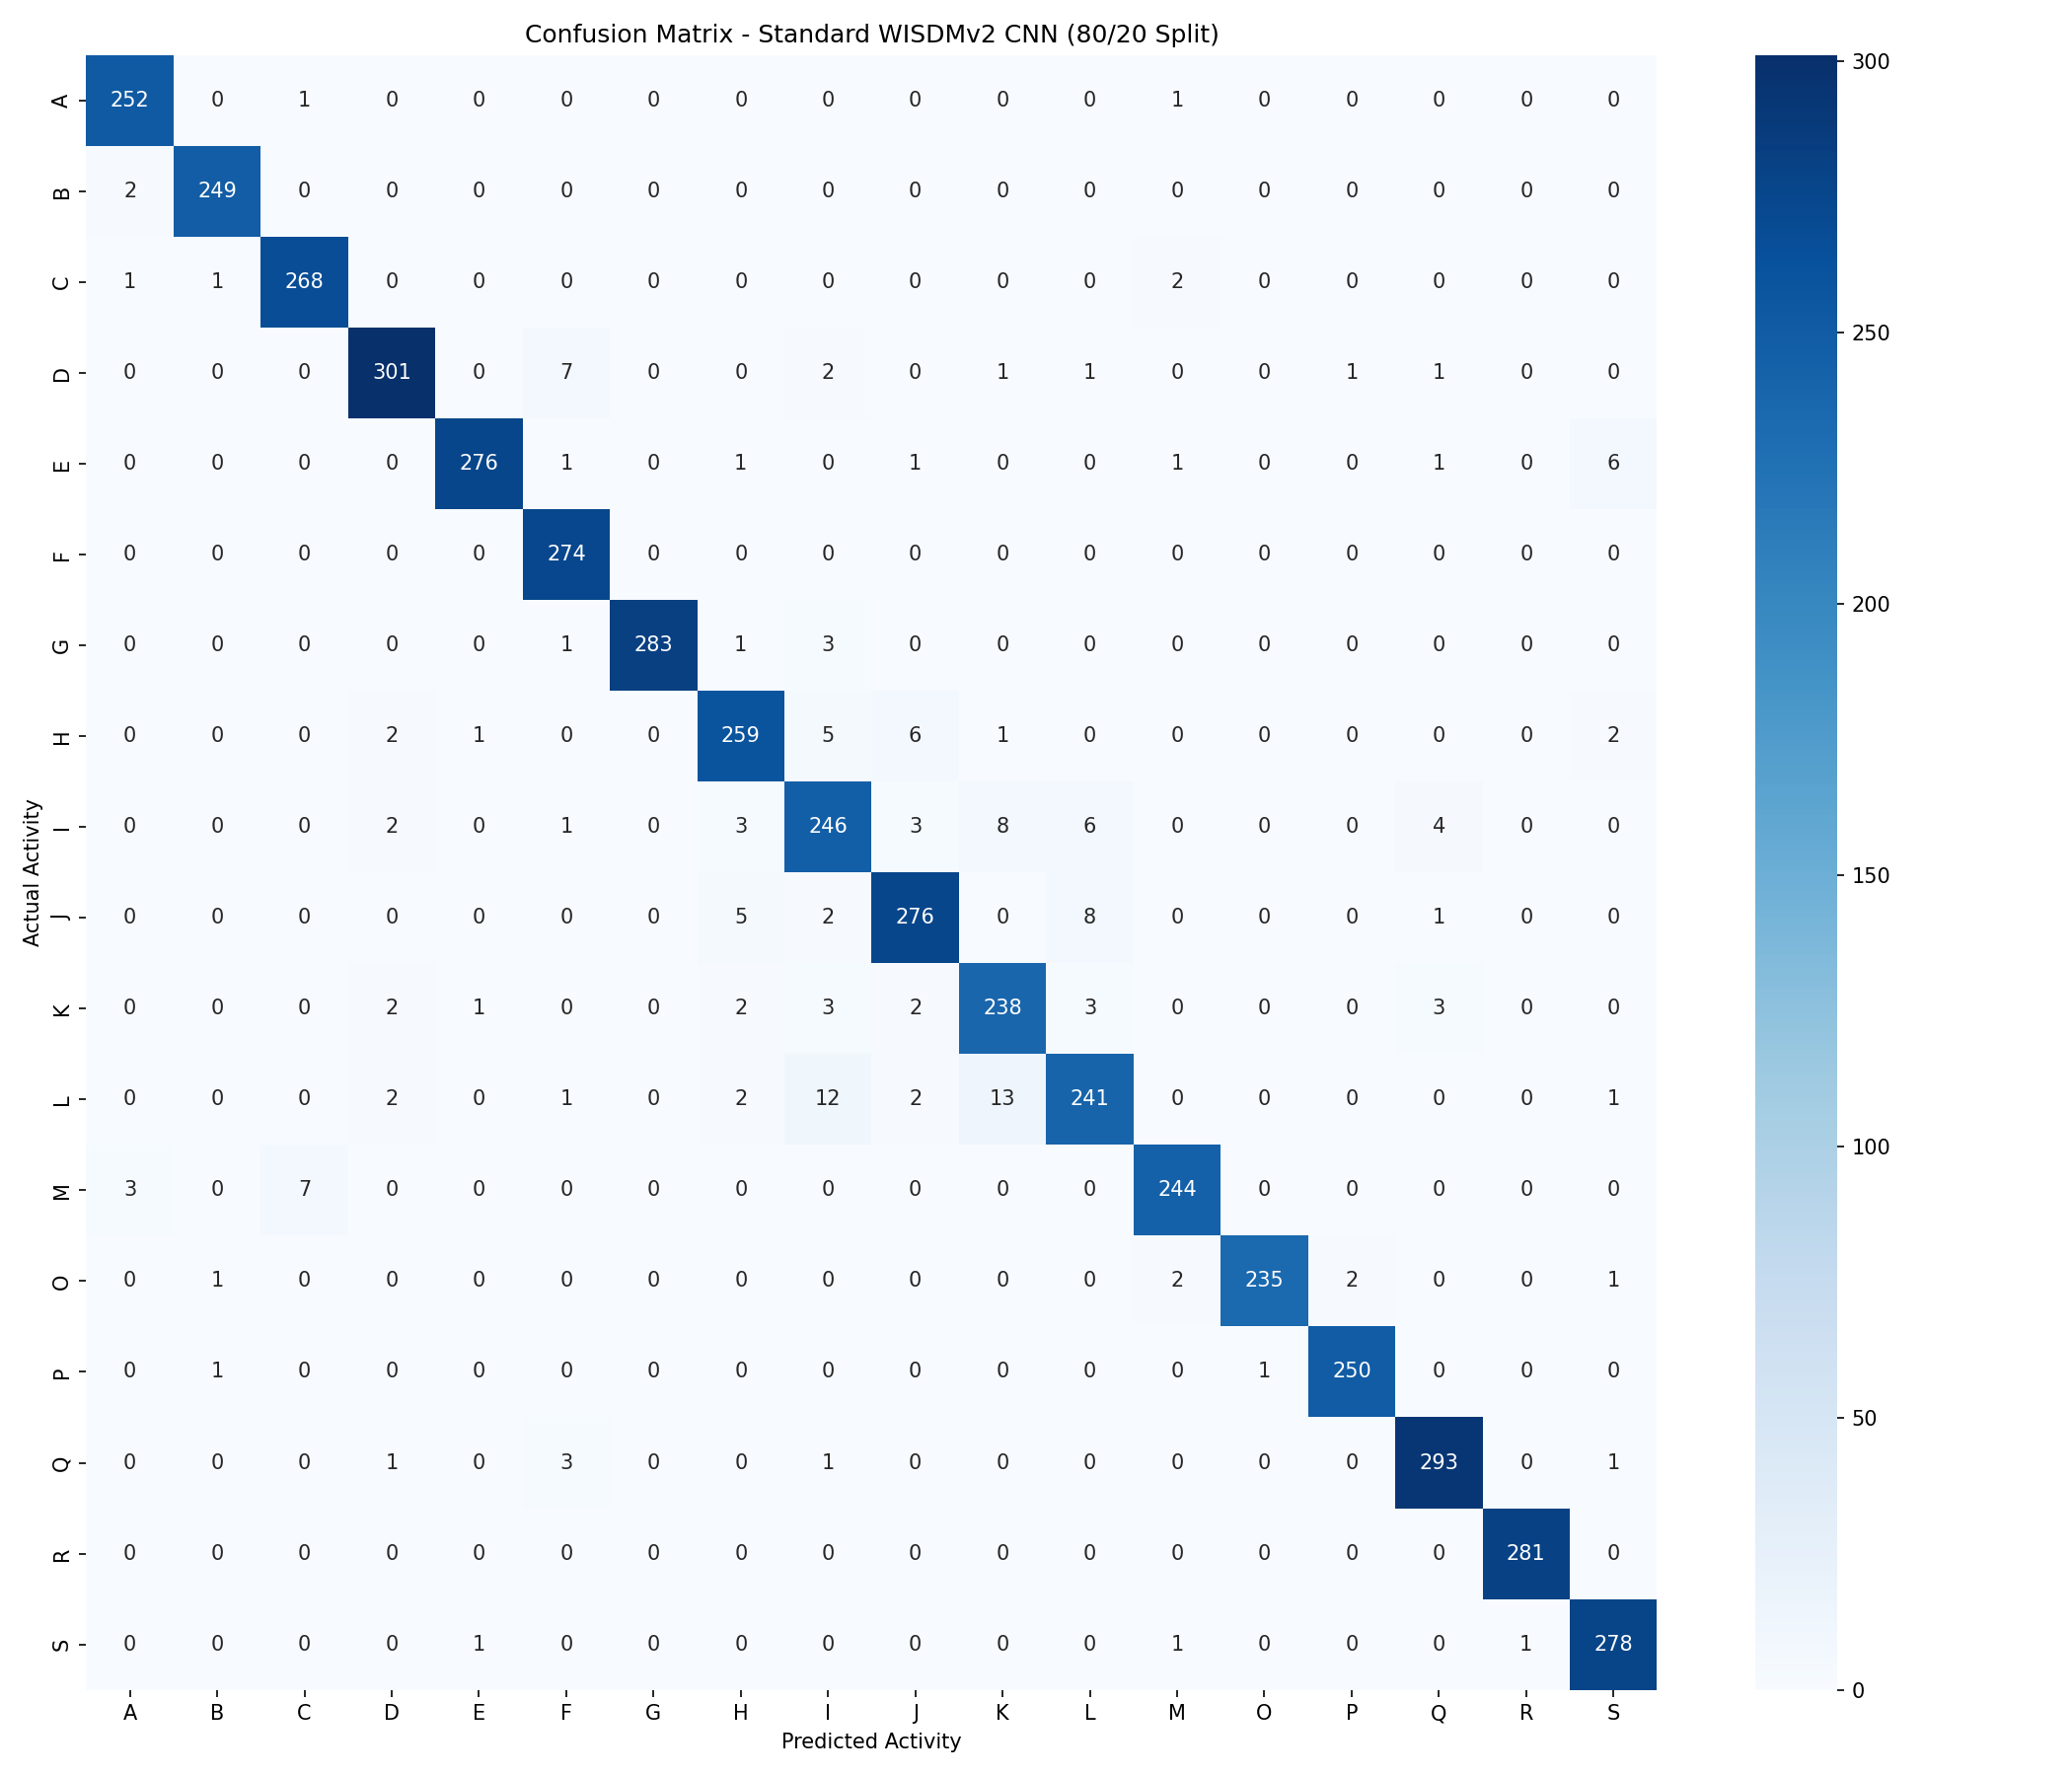

In [12]:
from IPython.display import Image, display

image_path = r'/content/d:\Project\confusion_matrix_80_20.png'
display(Image(filename=image_path))